In [1]:
import pandas as pd

wearable = pd.read_csv("../data/wearable_features_30d.csv")
survey = pd.read_csv("../data/survey_features.csv")

print(wearable.shape)
print(survey.shape)

(912, 54)
(1245, 14)


In [2]:
print(wearable.columns)
print(survey.columns)

Index(['egoid', 'wave', 'stress', 'datadate_mean', 'datadate_std',
       'complypercent_mean', 'complypercent_std', 'meanrate_mean',
       'meanrate_std', 'sdrate_mean', 'sdrate_std', 'steps_mean', 'steps_std',
       'floors_mean', 'floors_std', 'sedentaryminutes_mean',
       'sedentaryminutes_std', 'lightlyactiveminutes_mean',
       'lightlyactiveminutes_std', 'fairlyactiveminutes_mean',
       'fairlyactiveminutes_std', 'veryactiveminutes_mean',
       'veryactiveminutes_std', 'lowrangemins_mean', 'lowrangemins_std',
       'fatburnmins_mean', 'fatburnmins_std', 'cardiomins_mean',
       'cardiomins_std', 'peakmins_mean', 'peakmins_std', 'lowrangecal_mean',
       'lowrangecal_std', 'fatburncal_mean', 'fatburncal_std',
       'cardiocal_mean', 'cardiocal_std', 'peakcal_mean', 'peakcal_std',
       'bedtimedur_mean', 'bedtimedur_std', 'minstofallasleep_mean',
       'minstofallasleep_std', 'minsafterwakeup_mean', 'minsafterwakeup_std',
       'minsasleep_mean', 'minsasleep_std', 

In [3]:
# Merge wearable and survey features by student and wave.
merged_data = wearable.merge(
    survey,
    on=["egoid", "wave"],
    how="inner"
)

print(merged_data.shape)

(912, 66)


In [4]:
merged_data.head()

,egoid,wave,stress_x,datadate_mean,datadate_std,complypercent_mean,complypercent_std,meanrate_mean,meanrate_std,sdrate_mean,...,health,trust,sleep_quality,sedentary,exercise_alone,exercise_others,beer,wine,caffeine,tobacco
0,10237,5,2.0,2017-03-27 13:00:00.000000,9 days 04:38:35.981370,86.416667,21.400765,77.725359,5.284242,18.185866,...,2.0,3.166667,10.0,2.363636,2.0,4.0,2.0,2.0,4.0,3.0
1,10237,6,2.0,2017-10-31 12:00:00.000000,8 days 19:16:54.488423,93.133333,11.230296,78.689774,6.113357,18.848640,...,1.0,3.166667,9.0,4.454546,0.0,4.0,3.0,2.0,3.0,3.0
2,10469,4,2.6,2016-10-26 14:24:00.000000,9 days 01:51:31.211221,86.333333,16.872068,87.609175,4.389913,13.235560,...,1.0,2.666667,NaN,2.454546,0.0,0.0,2.0,2.0,3.0,3.0
3,10469,5,2.1,2017-04-09 21:00:00.000000,7 days 17:02:57.057545,84.437500,23.209104,88.637704,3.381754,11.991933,...,2.0,2.833333,10.0,1.181818,2.0,2.0,3.0,2.0,2.0,3.0
4,11002,4,1.1,2016-10-14 10:40:00.000000,3 days 04:56:29.530488,90.666667,17.457090,75.031066,8.311891,16.005319,...,0.0,3.833333,3.0,2.545454,1.0,1.0,1.0,1.0,0.0,3.0


In [5]:
merged_data.columns

Index(['egoid', 'wave', 'stress_x', 'datadate_mean', 'datadate_std',
       'complypercent_mean', 'complypercent_std', 'meanrate_mean',
       'meanrate_std', 'sdrate_mean', 'sdrate_std', 'steps_mean', 'steps_std',
       'floors_mean', 'floors_std', 'sedentaryminutes_mean',
       'sedentaryminutes_std', 'lightlyactiveminutes_mean',
       'lightlyactiveminutes_std', 'fairlyactiveminutes_mean',
       'fairlyactiveminutes_std', 'veryactiveminutes_mean',
       'veryactiveminutes_std', 'lowrangemins_mean', 'lowrangemins_std',
       'fatburnmins_mean', 'fatburnmins_std', 'cardiomins_mean',
       'cardiomins_std', 'peakmins_mean', 'peakmins_std', 'lowrangecal_mean',
       'lowrangecal_std', 'fatburncal_mean', 'fatburncal_std',
       'cardiocal_mean', 'cardiocal_std', 'peakcal_mean', 'peakcal_std',
       'bedtimedur_mean', 'bedtimedur_std', 'minstofallasleep_mean',
       'minstofallasleep_std', 'minsafterwakeup_mean', 'minsafterwakeup_std',
       'minsasleep_mean', 'minsasleep_std'

In [6]:
# Resolve duplicate stress columns created by the merge.
merged_data = merged_data.rename(columns={"stress_y": "stress"})
merged_data = merged_data.drop(columns=["stress_x"])

In [7]:
# Confirm columns after cleaning the stress field.
merged_data.columns

Index(['egoid', 'wave', 'datadate_mean', 'datadate_std', 'complypercent_mean',
       'complypercent_std', 'meanrate_mean', 'meanrate_std', 'sdrate_mean',
       'sdrate_std', 'steps_mean', 'steps_std', 'floors_mean', 'floors_std',
       'sedentaryminutes_mean', 'sedentaryminutes_std',
       'lightlyactiveminutes_mean', 'lightlyactiveminutes_std',
       'fairlyactiveminutes_mean', 'fairlyactiveminutes_std',
       'veryactiveminutes_mean', 'veryactiveminutes_std', 'lowrangemins_mean',
       'lowrangemins_std', 'fatburnmins_mean', 'fatburnmins_std',
       'cardiomins_mean', 'cardiomins_std', 'peakmins_mean', 'peakmins_std',
       'lowrangecal_mean', 'lowrangecal_std', 'fatburncal_mean',
       'fatburncal_std', 'cardiocal_mean', 'cardiocal_std', 'peakcal_mean',
       'peakcal_std', 'bedtimedur_mean', 'bedtimedur_std',
       'minstofallasleep_mean', 'minstofallasleep_std', 'minsafterwakeup_mean',
       'minsafterwakeup_std', 'minsasleep_mean', 'minsasleep_std',
       'minsawake

In [8]:
# Drop date summary features that are not useful model predictors.
merged_data = merged_data.drop(columns=[
    "datadate_mean",
    "datadate_std",
    "survey_date_mean",
    "survey_date_std"
])

In [9]:
merged_data.shape

(912, 61)

In [10]:
# Inspect features with the most missing values.
merged_data.isna().sum().sort_values(ascending=False).head(15)

sleep_quality                143
trust                          1
complypercent_mean             0
wave                           0
egoid                          0
meanrate_std                   0
sdrate_mean                    0
sdrate_std                     0
steps_mean                     0
steps_std                      0
floors_mean                    0
complypercent_std              0
meanrate_mean                  0
sedentaryminutes_std           0
lightlyactiveminutes_mean      0
dtype: int64

In [11]:
# Print quick dataset health metrics for sanity checking.
print("Rows:", merged_data.shape[0])
print("Columns:", merged_data.shape[1])
print("Students:", merged_data["egoid"].nunique())
print("Stress missing:", merged_data["stress"].isna().sum())

Rows: 912
Columns: 61
Students: 364
Stress missing: 0


In [12]:
# Impute selected survey features with their median values.
merged_data["sleep_quality"] = merged_data["sleep_quality"].fillna(
    merged_data["sleep_quality"].median()
)

merged_data["trust"] = merged_data["trust"].fillna(
    merged_data["trust"].median()
)

In [13]:
# Recheck missing values after imputation.
merged_data.isna().sum().sort_values(ascending=False).head(10)

egoid                 0
wave                  0
complypercent_mean    0
complypercent_std     0
meanrate_mean         0
meanrate_std          0
sdrate_mean           0
sdrate_std            0
steps_mean            0
steps_std             0
dtype: int64

In [14]:
# Separate predictors, target, and group labels.
X = merged_data.drop(columns=["stress"])
y = merged_data["stress"]
groups = merged_data["egoid"]

In [33]:
print("Unique stress values:", y.nunique())
# print(y.value_counts().sort_index())


Unique stress values: 38


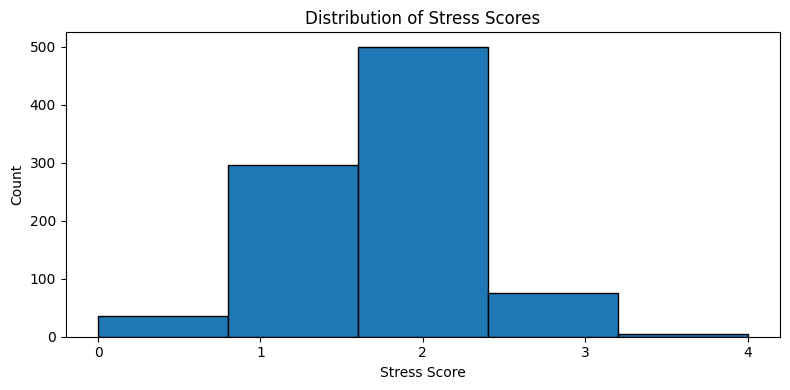

In [28]:
import matplotlib.pyplot as plt

y_rounded = y.round()

plt.figure(figsize=(8, 4))
plt.hist(y_rounded, bins=len(y_rounded.unique()), edgecolor="black", align="mid")
plt.xlabel("Stress Score")
plt.ylabel("Count")
plt.title("Distribution of Stress Scores")
plt.xticks(sorted(y_rounded.unique().astype(int)))
plt.tight_layout()
plt.show()

In [29]:
# Create a group-aware split so the same student is not in both sets.
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y_rounded.iloc[train_idx]
y_test = y_rounded.iloc[test_idx]

In [ ]:
print("Unique stress values:", y_train.nunique())

Unique stress values: 5


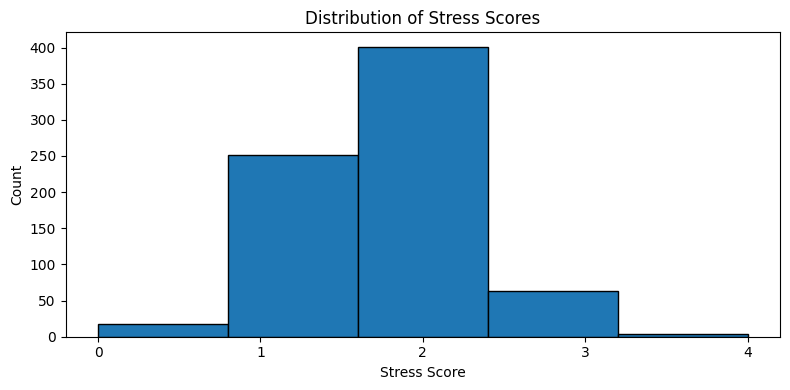

In [31]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 4))
plt.hist(y_train, bins=len(y_rounded.unique()), edgecolor="black", align="mid")
plt.xlabel("Stress Score")
plt.ylabel("Count")
plt.title("Distribution of Stress Scores")
plt.xticks(sorted(y_rounded.unique().astype(int)))
plt.tight_layout()
plt.show()

In [16]:
# Remove the identifier feature after splitting to avoid leakage.
X_train = X_train.drop(columns=["egoid"])
X_test = X_test.drop(columns=["egoid"])

In [17]:
# Verify split sizes and ensure no student overlap between sets.
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

train_students = set(merged_data.iloc[train_idx]["egoid"])
test_students = set(merged_data.iloc[test_idx]["egoid"])

print("Student overlap:", len(train_students.intersection(test_students)))

Train shape: (738, 59)
Test shape: (174, 59)
Student overlap: 0


In [30]:
# Train a mean baseline regressor and report benchmark metrics.
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)

print("Dummy MAE:", mean_absolute_error(y_test, dummy_pred))
print("Dummy R2:", r2_score(y_test, dummy_pred))

Dummy MAE: 0.618976419649254
Dummy R2: -0.013967989489127364


In [19]:
# Fit a Random Forest model on the combined feature set.
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest MAE:", mean_absolute_error(y_test, rf_pred))
print("Random Forest R2:", r2_score(y_test, rf_pred))

Random Forest MAE: 0.4966250303967048
Random Forest R2: 0.23293205349301382


In [20]:
# Fit an XGBoost regressor as an alternative nonlinear model.
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost MAE:", mean_absolute_error(y_test, xgb_pred))
print("XGBoost R2:", r2_score(y_test, xgb_pred))

XGBoost MAE: 0.5139921958584822
XGBoost R2: 0.1738563439608154


In [21]:
# Build and print Random Forest feature importance rankings.
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importances.head(15))

happy                        0.173487
trust                        0.053205
lowrangecal_mean             0.052155
sleep_quality                0.040003
lowrangecal_std              0.031195
wave                         0.028685
sedentary                    0.024216
floors_mean                  0.020575
sedentaryminutes_std         0.020570
lightlyactiveminutes_std     0.019308
minstofallasleep_std         0.017385
fatburncal_std               0.017170
sedentaryminutes_mean        0.016489
lightlyactiveminutes_mean    0.016416
meanrate_std                 0.015817
dtype: float64


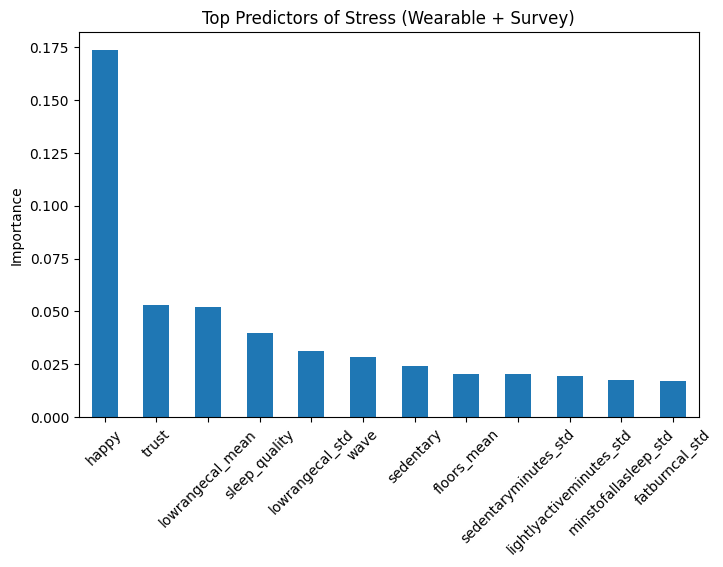

In [22]:
# Visualize the top feature importances from the Random Forest model.
plt.figure(figsize=(8,5))
importances.head(12).plot(kind="bar")
plt.title("Top Predictors of Stress (Wearable + Survey)")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

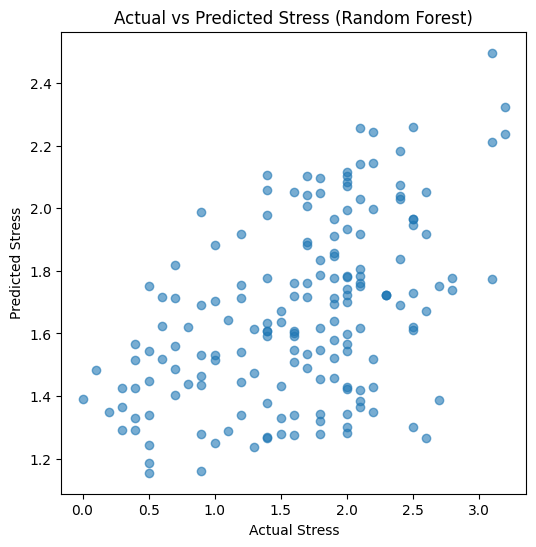

In [23]:
# Compare true and predicted stress values with a scatter plot.
plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_pred, alpha=0.6)
plt.xlabel("Actual Stress")
plt.ylabel("Predicted Stress")
plt.title("Actual vs Predicted Stress (Random Forest)")
plt.show()

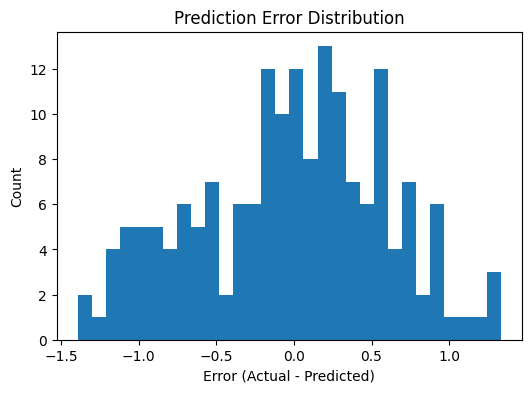

In [24]:
# Plot residuals to inspect model error distribution.
errors = y_test - rf_pred

plt.figure(figsize=(6,4))
plt.hist(errors, bins=30)
plt.title("Prediction Error Distribution")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Count")
plt.show()

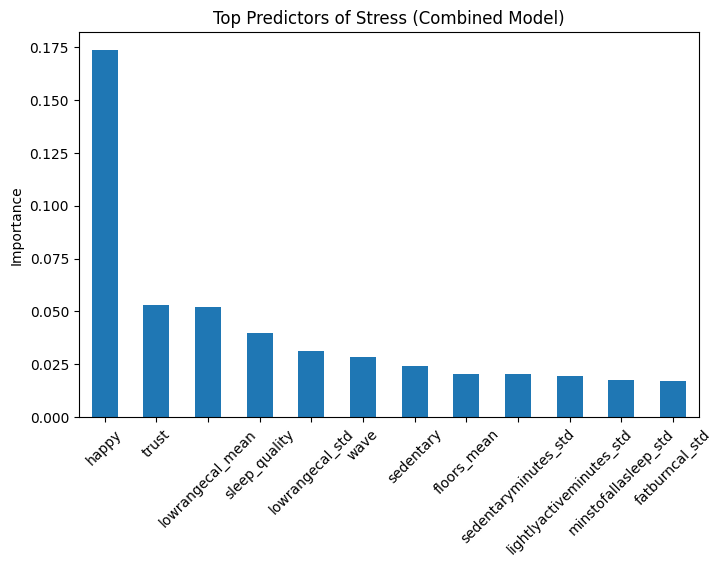

In [25]:
# Replot the top predictors for the final combined model summary.
plt.figure(figsize=(8,5))
importances.head(12).plot(kind="bar")
plt.title("Top Predictors of Stress (Combined Model)")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()
